---
title: Metamet. A Toolkit for Meteorological Data Standardisation  
short_title: Metamet Notebook  
description: metamet is an R package which attempts to solve many of the problems encountered in working with meteorological observation data.  
  
date: 2026-07-30  
updated: 2026-07-30  

license:  
  code: MIT  
  content: MIT + file LICENSE  

github: https://github.com/NERC-CEH/metamet  
thumbnail: "./images/logo.png"  

authors:
  - name: Peter E. Levy  
    orcid: https://orcid.org/0000-0002-8505-1901  
    corresponding: true  
    email: plevy@ceh.ac.uk  
    affiliations:  
      - name: UK Centre for Ecology and Hydrology (UKCEH)  
        ror: https://ror.org/00pggkr55  
  - name: Claudia Caporusso  
    orcid: https://orcid.org/0009-0001-2852-4880  
    corresponding: false  
    email: clacap@ceh.ac.uk  
    affiliations:  
      - name: UK Centre for Ecology and Hydrology (UKCEH)  
        ror: https://ror.org/00pggkr55  
  - name: James M. Cash  
    orcid: https://orcid.org/0000-0002-8567-1377  
    corresponding: false  
    email: jamcas@ceh.ac.uk  
    affiliations:  
      - name: UK Centre for Ecology and Hydrology (UKCEH)  
        ror: https://ror.org/00pggkr55  
  - name: Karen Hei-Laan Yeung  
    orcid: https://orcid.org/0009-0006-0400-3980  
    corresponding: false  
    email: karung@ceh.ac.uk  
    affiliations:  
      - name: UK Centre for Ecology and Hydrology (UKCEH)  
        ror: https://ror.org/00pggkr55  

funding:
  - statement: This research was supported by NERC, through the UKCEH National Capability for UK Challenges Programme NE/Y006208/1.
    awards:
      - id: NE/Y006208/1
        name: UKCEH National Capability for UK Challenges Programme
        sources:
          - name: NERC
---

# Metamet. A Toolkit for Meteorological Data Standardisation  

## Challenge and Methodological Approach Summary

Meteorological data from field sites is messy: different loggers save data in different formats, sites don't always use the same variable names or units, and raw records contain sensor errors and gaps that need to be checked and fixed before the data can be used. [`metamet`](https://github.com/NERC-CEH/metamet) is an R package which attempts to solve many of the problems encountered in working with meteorological observation data. It provides a system for:

- standardising metadata
- converting between file formats
- converting between variable naming conventions
- converting units
- automating QA/QC
- facilitating manual QA/QC via a shiny app
- imputing missing values or "gap-filling"

It does this by defining:

1. a standardised generic data structure with enough complexity to hold both the 
observational data and the metadata, including site-specific, variable-specific 
and individual record-specific metadata; and
2. methods/functions for converting data between formats, combining data from 
different sources, quality control and gap-filling.

This notebook demonstrates some of the functionality, for more detail see [metamet package documentation](https://nerc-ceh.github.io/metamet/).

::::{admonition} Running the code
:class: note, dropdown

This method is written in **R** and would normally be run in an R-focused development environment such as **RStudio**. For full details on the `metamet` package, including installation instructions, available functions, and examples, see the [metamet package documentation](https://nerc-ceh.github.io/metamet/).

The notebook you are currently viewing has been created specifically for the **Environmental Data Science Toolbox**. It uses Jupyter's support for **R kernels** so that the method can be presented and executed as an `.ipynb` notebook within Jupyter Book.

To run the notebook yourself, you will need:

- R
- Jupyter, with the jupyter command available on your system PATH
- A Jupyter-compatible interface such as VS Code with the Jupyter extension

After cloning the repository, open an R session in the `notebook/` directory and restore the supplied `renv` environment:

```r
install.packages("renv")
renv::restore()
```

This recreates the project-specific R library from `renv.lock`, including `IRkernel` and the R packages required by the notebook.

Before registering the R kernel, check that Jupyter is visible from the same R session:

```r
Sys.which("jupyter")
```

This should return the path to a Jupyter executable. If it returns an empty string, Jupyter is either not installed or is not available on the `PATH` inherited by R. For example, if Jupyter is installed in a Conda environment, activate that environment before starting R:

```bash
conda activate <jupyter-environment> 
cd path/to/metamet/notebook 
R
```

You can then register the restored R kernel with Jupyter:

```r
IRkernel::installspec(
    name = "metamet-r",
    displayname = "R - metamet"
)
```

Kernel registration is a local, one-off setup step for each machine and is not stored in the repository.

Finally, open the `.ipynb` file in VS Code or another Jupyter-compatible interface and select R - metamet as the notebook kernel. The notebook should then run using the R packages restored from the supplied renv.lock.

If you only want to use the `metamet` package itself rather than this Toolbox notebook, the package documentation and standard R/RStudio workflow are the recommended starting point.
::::


::::{tab-set}
:::{tab-item} Data Access
:sync: tab1
The notebook uses sample data bundled with the package under `inst/extdata` for three UK sites (UK-AMO, UK-EBU, UK-WHM), so you can run everything without downloading anything separately. The Whim Moss (UK-WHM) data are also publicly available from the [EIDC data centre](https://catalogue.ceh.ac.uk/documents/ba9ecad2-1740-41e6-8f73-b308340d49fe). A small extract of ERA5 reanalysis data is included as reference data for gap-filling; the full ERA5 dataset can be obtained from the [Copernicus Climate Data Store](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels).
:::
:::{tab-item} Assumptions
:sync: tab2
The method assumes each variable already has metadata defining its valid range and a sensible default gap-filling method - this has to be set up once per site/variable and is what makes the automated QC and imputation work. It also assumes timestamps are in UTC, and that ERA5 (or another reference dataset) is a reasonable proxy for the true value when substituting for missing data.
:::
:::{tab-item} Generalisability
:sync: tab3
Because the data structure and QC logic are driven by metadata rather than hard-coded per variable, `metamet` should generalise to any met or flux tower site, regardless of logger type or file format, as long as the site's variables and ranges can be described in the metadata tables. Adding a new site or variable is mostly a matter of adding a row to the metadata, not writing new code.
:::
:::{tab-item} Limitations
:sync: tab4
The imputation methods provided (interpolation, regression, ERA5 substitution, etc.) are simple and may not suit variables with more complex physical behaviour. ERA5 is also fairly coarse spatially, so substitution may be less reliable for sites in complex terrain or microclimates. Setting up metadata for a new site still requires some manual work, and the package hasn't been tested against every possible logger format or file convention in use.
:::
::::

## Getting started with the Shiny app

`metamet` includes an interactive Shiny application for manual QA/QC and gap-filling of meteorological data. The app lets you build a `metamet` object from raw data files, inspect and correct observations interactively, and export the processed data.

### Install app dependencies

If not using renv.lock file then install dependencies using:

In [29]:
# install.packages("pak")
# pak::pak("NERC-CEH/metamet", dependencies = TRUE)

### Launch the app

In [3]:
metamet::run_shiny()


Listening on http://127.0.0.1:6755



![metamet-app-screenshot](./images/metamet-app.png "Title")

### App workflow overview

The app guides you through a four-stage workflow:

1. **Create or open a `metamet` object** – Use the *Create new Metamet object*
   wizard to import a raw data file (CSV, Campbell TOA5, old Campbell `.dat`/`.dld`,
   or CEDA BADC-CSV), map variables to ICOS names, set QC ranges, and optionally
   attach ERA5 reference data. The wizard saves the result as a `.rds` file.
   Alternatively, use *Open existing Metamet object* to load a previously saved `.rds`.

2. **Select date range and QA/QC** – Choose a start and end date/time, click
   *Retrieve from database*, then inspect each variable in its own interactive
   plot tab. Select suspect data points with the lasso tool, pick a gap-filling
   method (time interpolation, regression, ERA5 substitution, or others), add an
   optional comment explaining the change, and click *Impute selection*. Click
   *Finished checking variable* when a variable is signed off.

3. **Save changes** – Click *Save changes* to write a new `.rds` file (named with
   your system username and today's date) plus a CEDA-formatted output in the same
   directory as the source file.

4. **Download processed data** – Export Level 1, Level 2, or CEDA-formatted data
   as `.csv` (or `.zip` for Level 1/2) from the *Download processed data* tab.

For a detailed walkthrough see the
[App User Guide](https://nerc-ceh.github.io/metamet/articles/app_user_guide.html).

## Basic metamet workflow - create a metamet object without the app

Basic usage is to first create `metamet` objects from files or pre-existing data 
frames or data tables. Because all the metadata describing the observations is
available in the structure, objects can be processed relatively easily so as to:

- rename variables in standard naming conventions
- combine data from different sites
- apply quality control
- impute missing data.

Firstly, we load the `metamet` library, as well as the `here` library which 
simplifies specifying file paths.

In [4]:
library(metamet)
library(here)

here::i_am("notebook/metamet_notebook.ipynb")

fname_dt <- here::here("inst", "extdata", "UK-AMO", "UK-AMO_BM_dt_2026.csv")
fname_meta <- here::here("inst", "extdata", "dt_meta.csv")
fname_site <- here::here("inst", "extdata", "dt_site.csv")

mm <- metamet(
  dt = fname_dt,
  dt_meta = fname_meta,
  dt_site = fname_site,
  site_id = "UK-AMO"
)

# print the outline strucutre:
mm

Warning message:
"package 'here' was built under R version 4.5.3"


here() starts at C:/Users/jercar/OneDrive - UKCEH/Git-Repositories/tests/metamet/notebook

here() starts at C:/Users/jercar/OneDrive - UKCEH/Git-Repositories/tests/metamet

Loading file: C:/Users/jercar/OneDrive - UKCEH/Git-Repositories/tests/metamet/inst/extdata/UK-AMO/UK-AMO_BM_dt_2026.csv

Reading data table ...



DATECT,TS,SWC,G,WTD,WTD_4_1_1,PA_4_1_1,SW_IN,SW_OUT,LW_IN,⋯,TA_4_1_1,RH_4_1_1,RG_4_1_0,NDVI_649IN_5_1_1,NDVI_649OUT_5_1_1,NDVI_797IN_5_1_1,NDVI_797OUT_5_1_1,LWS_4_1_1,LWS_4_1_2,site
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2026-01-01 00:30:00,4.704447,66.78342,-5.243817,0.03166667,NA,97.45738,0.0000000,0.0000000,300.7320,⋯,4.197793,90.66898,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,322.2309,298.0167,UK-AMO
2026-01-01 01:00:00,4.710880,66.78225,-5.135017,0.03091667,NA,97.39056,0.0000000,0.0000000,295.8329,⋯,4.195574,90.86098,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,323.0151,298.4208,UK-AMO
2026-01-01 01:30:00,4.716867,66.78408,-5.046967,0.02978333,NA,97.39056,0.0000000,0.0000000,295.8329,⋯,4.195574,90.86098,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,323.0151,298.4208,UK-AMO
2026-01-01 02:00:00,4.722013,66.78121,-4.993383,0.02945000,NA,97.31761,0.0000000,0.0000000,278.5072,⋯,3.740857,90.69958,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,322.3558,298.0811,UK-AMO
2026-01-01 02:30:00,4.726623,66.78179,-4.970217,0.02666667,NA,97.31761,0.0000000,0.0000000,278.5072,⋯,3.740857,90.69958,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,322.3558,298.0811,UK-AMO
2026-01-01 03:00:00,4.730317,66.78275,-4.974533,0.02293333,NA,97.29941,0.0000000,0.0000000,262.7314,⋯,2.908084,88.10049,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,311.7404,292.6100,UK-AMO
2026-01-01 03:30:00,4.731863,66.78671,-5.023100,0.01990000,NA,97.29941,0.0000000,0.0000000,262.7314,⋯,2.908084,88.10049,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,311.7404,292.6100,UK-AMO
2026-01-01 04:00:00,4.730487,66.79171,-5.156133,0.01720000,NA,97.30384,0.0000000,0.0000000,257.7812,⋯,2.003895,83.79506,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,294.1556,283.5469,UK-AMO
2026-01-01 04:30:00,4.726977,66.79250,-5.363500,0.01688333,NA,97.30384,0.0000000,0.0000000,257.7812,⋯,2.003895,83.79506,0.000000,-0.042008753,-0.1865732,0.004099294,-0.06082769,294.1556,283.5469,UK-AMO



A typical workflow would go on to perform tasks such as adding reference data 
from ECMWF ERA5 reanalysis, join with other `metamet` objects, apply quality 
control algorithms, impute missing values by various algorithms, and check the 
data manually for additional QC. This is illustrated  below.

In [5]:
fname_era5 <- here::here("inst", "extdata", "dt_era5.csv")

mm <- add_era5(
  mm,
  fname_era5 = fname_era5
)
# mm <- join(mm, mm_old)
mm <- apply_qc(mm)
mm <- impute(mm = mm)
run_shiny()


[1] "Getting ready to impute TS"
[1] "using method 7 era5"


Saving 7 x 7 in image


[1] "Getting ready to impute SWC"
[1] "using method 7 era5"


Saving 7 x 7 in image


[1] "Getting ready to impute G"
[1] "using method 7 era5"


...

[1] "Getting ready to impute RG"
[1] "using method 7 era5"


Saving 7 x 7 in image


[1] "Getting ready to impute NDVI_649IN"
[1] "using method 4 nightzero"


Warning message:
"tz(): Don't know how to compute timezone for object of class NULL; returning "UTC"."


ERROR: Error in UseMethod("reclass_date", orig): no applicable method for 'reclass_date' applied to an object of class "NULL"



Clearly a two-dimensional data table is not sufficient to hold all the 
information. Instead we define a `metamet` data object as a set of related data 
tables. We implement this as a list in R, containing five data tables (prefix `dt_`) 
explained in the table below.

| Name | Type | Contains | Rows correspond to | Columns correspond to |
|---|---|---|---|---|
| dt | data.table | sensor data | time intervals | variables |
| dt_meta | data.table | variable- and time-specific meta data (like netCDF data attributes) e.g. coords for sensor locations | variables x time period | metadata variables |
| dt_site | data.table | site-specific meta data (like netCDF global attributes) | sites | metadata variables |
| dt_qc | data.table | QC codes | time intervals | variables |
| dt_ref | data.table | ref data e.g. era5 | time intervals | variables |


The following provides an example of how to structure the rest of your notebook. Use headings, sub-headings, and a mix of code cells and markdown cells to guide others through your method step-by-step.

## Met Data Standards

The most basic problem is simply of agreeing on standard names for variables.
Several conventions exist, but none are widely used outside the modelling
community. Some naming conventions are listed below.
  

| Name | Defines | Link | Issues |
|---|---|---|---|
| Climate Forecast (CF) | Names & netCDF file format | [link](https://cfconventions.org/Data/cf-standard-names/docs/guidelines.html), and [from CEDA](https://help.ceda.ac.uk/article/4507-the-cf-metadata-convention) |
| ICOS | Variable names | [link](https://www.icos-etc.eu/icos/documents/instructions/bmform) | |
| ERA5 | Variable names | [link](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=documentation) | |
| AmeriFlux BADM | Variable names | [link](/ameriflux.lbl.gov/data/badm/badm-standards/) | Does not including most met variables |
| Copernicus Station Exchange Format (SEF) | Variable names | [link](https://datarescue.climate.copernicus.eu/variablenames) | |
| Copernicus Station Exchange Format (SEF) | Plain text file format  | [link](https://datarescue.climate.copernicus.eu/station-exchange-format-sef) | Only one variable per file limits use |
| CEDA BADC-CSV | Plain text file format  | [link](https://help.ceda.ac.uk/article/105-badc-csv) | Format not easily machine-readable |

  
These conventions are not systematically constructed, so are not
easily extended or modified to be more generally useable; several are not even 
easily machine-readable.
For example, the Climate Forecast (CF) convention constructs a set of [standard
names](https://cfconventions.org/Data/cf-standard-names/docs/guidelines.html) 
used widely in climate modelling. Users are able to suggest new variables names 
in an ad hoc manner. The result is there are ~5250 arbitrarily defined variable 
names, with no system to their naming. For example, there is no system to the 
naming to group together different types of temperature measurements (such as soil 
temperature, surface temperature, air temperature at 2 m or 10 m).
Eleven chemical species are defined, but arbitraryily, so no other chemical 
species can be referred to without inventing new names.

Because none of these is widely used in the measurement community, we need to 
build the flexibility to: 

- allow easy conversion of ad hoc local naming schemes into one or more standards, and 
- translate easily between different existing standards (e.g. ERA5 to CF-1).

## Workflow Example 1

This vignette illustrates the typical workflow for processing met data with 
`metamet`. The basic steps are to:

- read the observation data
- create a corresponding metadata table `dt_meta` for the observed variables 
- create a metadata table `dt_site` for each site with observations
- combine these into a single `metamet` object

## Example data

To illustrate, we will use some publicy available data from Whim Moss, available
from the [EIDC data centre](https://catalogue.ceh.ac.uk/documents/ba9ecad2-1740-41e6-8f73-b308340d49fe).
Metadata are available in the supporting documentation, but not in a 
machine-readable format, so we have to extract it manually the first time. 
Thereafter it is available within the `metamet` object for all future use.

### Observation data `dt`

Having downloaded the observation data, we can read it from a file and display 
a few rows.

In [6]:
fname <- here("inst/extdata/UK-WHM/historical/eidc/whim_met_2002_2023.csv")

dt <- data.table::fread(fname)
dim(dt)
dt

[1] 736321     14

Timestamp,Rain,LWS,AirT,RH,PAR,Total_solar,Net_rad,WS,WD,Soil_VWC,Soil_T1,Soil_T2,WTD
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
01/01/2003 00:00,0,6999.0,1.534,93.9,NA,0,-23.820,5.605,153.800,NA,3.979,4.441,NA
01/01/2003 00:15,0,6999.0,1.509,93.8,NA,0,-33.320,5.713,160.800,NA,3.984,4.438,NA
01/01/2003 00:30,0,6999.0,1.354,94.3,NA,0,-37.650,5.388,157.700,NA,3.967,4.430,NA
01/01/2003 00:45,0,6999.0,1.359,94.5,NA,0,-25.340,5.675,157.100,NA,3.960,4.426,NA
01/01/2003 01:00,0,6999.0,1.350,94.5,NA,0,-26.670,5.320,155.800,NA,3.946,4.418,NA
01/01/2003 01:15,0,6999.0,1.373,94.5,NA,0,-22.670,5.602,159.400,NA,3.953,4.416,NA
01/01/2003 01:30,0,6999.0,1.415,94.6,NA,0,-14.810,5.232,157.800,NA,3.932,4.408,NA
01/01/2003 01:45,0,6999.0,1.464,94.3,NA,0,-7.790,5.397,156.500,NA,3.920,4.401,NA
01/01/2003 02:00,0,6999.0,1.549,93.7,NA,0,-5.362,5.150,154.000,NA,3.916,4.398,NA


The data consist of a timestamp column, and 13 variables observed every 15 
minutes from 2003 until 2023, giving `r nrow(dt)` rows and `r ncol(dt)` columns.

### Observation metadata `dt_meta`

In [7]:
fname <- here("inst/extdata/dt_meta.csv")
dt_meta <- data.table::fread(fname)

v_col <- c(
  "site",
  "name_dt",
  "name_local",
  "units_local",
  "type",
  "time_char_format",
  # "start_date",
  # "end_date",
  # "horizontal_id",
  # "vertical_id",
  # "replicate_id",
  # "gf_time",
  # "gf_era5",
  # "gf_night_zero",
  # "diff_ref_max",
  # "sensor_make",
  # "sensor_model",
  "range_min",
  "range_max",
  "name_era5",
  "units_era5",
  "imputation_method"
)


In [8]:
knitr::kable(dt_meta[site == "UK-WHM", ..v_col])



|site   |name_dt     |name_local  |units_local |type           |time_char_format | range_min| range_max|name_era5 |units_era5 |imputation_method |
|:------|:-----------|:-----------|:-----------|:--------------|:----------------|---------:|---------:|:---------|:----------|:-----------------|
|UK-WHM |AirT        |AirT        |degC        |temperature    |                 |       -40|        50|t2m       |degC       |era5              |
|UK-WHM |LWS         |LWS         |1           |arbitrary      |                 |    -99999|     99999|rh        |1          |era5              |
|UK-WHM |Net_rad     |Net_rad     |W/m^2       |energy flux    |                 |      -500|      1200|rn        |W/m^2      |era5              |
|UK-WHM |PAR         |PAR         |umol/m^2/s  |energy flux    |                 |         0|      2200|ssrd      |umol/m^2/s |era5              |
|UK-WHM |Rain        |Rain        |mm          |precipitation  |                 |         0|        50|tp        |m

### Site data `dt_site`

The site metadata required is minimal. Any additional variables can be added, 
but at a minimum we require the site name, a uniquely identifying code `site`,
longitude, latitude (in degrees with a decimal fraction) and elevation (in m).
These are easily gleaned from the supporting documentation and could be entered
in excel, read in as a .csv text file, or entered directly in R as below.

In [9]:
dt_site <- data.table::data.table(
  site = "UK-WHM",
  long_name = "Whim Moss",
  lon = -3.27155,
  lat = -55.76566,
  elev = 316
)
dt_site

site,long_name,lon,lat,elev
<chr>,<chr>,<dbl>,<dbl>,<dbl>
UK-WHM,Whim Moss,-3.27155,-55.76566,316


In practice, we are likely to have multiple sites as in the table below, and it
is easiest to append rows to a .csv or excel file as new sites are added.

In [10]:
fname <- here("inst/extdata/dt_site.csv")
dt_site <- data.table::fread(fname)
knitr::kable(dt_site)



|site   |long_name        |       lon|      lat| elev|
|:------|:----------------|---------:|--------:|----:|
|UK-AMO |Auchencorth Moss | -3.243000| 55.79230|  120|
|UK-EBU |Easter Bush      | -3.207100| 55.86740|  119|
|UK-WHM |Whim Moss        | -3.271550| 55.76566|  316|
|UK-BUC |Bush Cabin       | -3.205767| 55.86227|  189|

## Workflow Example 2

This vignette illustrates the typical workflow for quality control of met data 
from multiple sites simultaneously with `metamet`. We assume that the basic 
steps have been carried out already: reading the raw observation data, creating 
systematic metadata for the variables and each site (described 
in [Workflow Example 1](workflow_example.html)).
This produces a single `metamet` object for each site.

First, we read the data for each of three sites
from file. 

In [11]:
library(ggplot2)

mm_amo <- readRDS(
  file = here::here("inst/extdata/UK-AMO/UK-AMO_BM_mm_2023.rds")
)
mm_ebu <- readRDS(
  file = here::here("inst/extdata/UK-EBU/UK-EBU_BM_mm_2023.rds")
)
mm_whm <- readRDS(
  file = here::here("inst/extdata/UK-WHM/UK-WHM_BM_mm_2023.rds")
)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


This gives us all the half-hourly data for 2023 from each site.  If we want to
process a shorter time period, we can subset as required with `subset_by_date`.
Here we look at two days just for speed.

In [12]:
mm_amo <- subset_by_date(mm_amo, "2023-09-01", "2023-09-03")
mm_ebu <- subset_by_date(mm_ebu, "2023-09-01", "2023-09-03")
mm_whm <- subset_by_date(mm_whm, "2023-09-01", "2023-09-03")

In order to combine data from different sites in a meningful way, they all need
to use the same naming convention. Here we convert two of the sites to the ICOS
convention using the `change_naming_convention` function below (UK-AMO data are
already produced in this form).

In [13]:
mm_ebu <- change_naming_convention(mm_ebu, name_convention = "name_icos")
mm_whm <- change_naming_convention(mm_whm, name_convention = "name_icos")

Although the base names of variable are now standardised across sites, the 
specific variables measured will vary across sites. For example, one site may
have two replicate measurements of air temperature TA_4_1_1 and TA_5_1_1, while
another has a single replicate TA_1_1_1. These cannot be combined as a single 
variable (or related variables) in wide format. Also, wide format would require
columns for the full set of variables found across all sites, many of which will
be empty for all sites except one. The efficient solution is to convert to long
format, so all values are in a single column, with additional columns to 
identify the site, timestamp, varaiable type and specific varaiable name. We do
this with the `reshape_wide_to_long` function, shown below.

In [14]:
mm_amo <- metamet_reshape(mm_amo, "long")
mm_ebu <- metamet_reshape(mm_ebu, "long")
mm_whm <- metamet_reshape(mm_whm, "long")

Warning message:
"metamet object has no format attribute; assuming 'wide'"
Warning message:
"metamet object has no format attribute; assuming 'wide'"


We can now see the structure of UK-AMO data 

In [15]:
mm_amo$dt

site,TIMESTAMP,var_name,value,type,name_icos,qc,validator,comment,ref
<chr>,<dttm>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
UK-AMO,2023-08-31 23:00:00,TS,12.1261067,temperature,TS,0,auto,NA,1.215084e+01
UK-AMO,2023-08-31 23:00:00,SWC,75.7363129,soil moisture,SWC,0,auto,NA,3.359879e+01
UK-AMO,2023-08-31 23:00:00,G,2.0565167,energy flux,G,0,auto,NA,-6.467518e-14
UK-AMO,2023-08-31 23:00:00,WTD,-0.3442333,height,WTD,0,auto,NA,3.359879e+01
UK-AMO,2023-08-31 23:00:00,WTD_4_1_1,NA,height,WTD,1,auto,NA,3.359879e+01
UK-AMO,2023-08-31 23:00:00,PA_4_1_1,97.6219900,pressure,PA,0,auto,NA,9.753263e+01
UK-AMO,2023-08-31 23:00:00,SW_IN,0.0000000,energy flux,SW_IN,0,auto,NA,-6.467518e-14
UK-AMO,2023-08-31 23:00:00,SW_OUT,0.0000000,energy flux,SW_OUT,0,auto,NA,-3.233759e-14
UK-AMO,2023-08-31 23:00:00,LW_IN,312.3000000,arbitrary,LW_IN,0,auto,NA,3.306637e+02


and see it is identical to the structure of UK-EBU (and UK-WHM) data.

In [16]:
mm_ebu$dt

site,TIMESTAMP,var_name,value,type,name_icos,qc,validator,comment,ref
<chr>,<dttm>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
UK-EBU,2023-08-31 23:00:00,RH_1_1_1,77.690,humidity,RH,0,auto,NA,8.500910e+01
UK-EBU,2023-08-31 23:00:00,TA_1_1_1,12.380,temperature,TA,0,auto,NA,1.179978e+01
UK-EBU,2023-08-31 23:00:00,LWS_7_1_1,268.300,arbitrary,LWS,0,auto,NA,8.500910e+01
UK-EBU,2023-08-31 23:00:00,PA_1_1_1,98.700,pressure,PA,0,auto,NA,9.753263e+01
UK-EBU,2023-08-31 23:00:00,P_1_1_1,0.000,precipitation,P,0,auto,NA,1.075824e-08
UK-EBU,2023-08-31 23:00:00,RN_7_1_1,-22.950,energy flux,RN,0,auto,NA,-3.940325e+01
UK-EBU,2023-08-31 23:00:00,SW_IN_1_1_1,0.001,energy flux,SW_IN,0,auto,NA,-6.467518e-14
UK-EBU,2023-08-31 23:00:00,PPFD_IN_1_1_1,0.116,energy flux,PPFD_IN,0,auto,NA,-6.467518e-14
UK-EBU,2023-08-31 23:00:00,SWC_5_1_1,11.400,soil moisture,SWC,0,auto,NA,3.359879e+01


Given this structure, we can simply append all the rows for all data tables to
create a single `metamet` object.

In [17]:
mm <- rbind_metamet(
  mm_amo,
  l_dt = list(mm_amo$dt, mm_ebu$dt, mm_whm$dt),
  l_dt_meta = list(mm_amo$dt_meta, mm_ebu$dt_meta, mm_whm$dt_meta),
  l_dt_site = list(mm_amo$dt_site, mm_ebu$dt_site, mm_whm$dt_site)
)

We can now plot all the variables of a given type for all the types, identifying
site by colour or separate panels (facets). Below we plot soil temperature 
against time; the solid black line shows the reference data, which in this case 
is ERA5 reanalysis data for the grid cell containing the site.

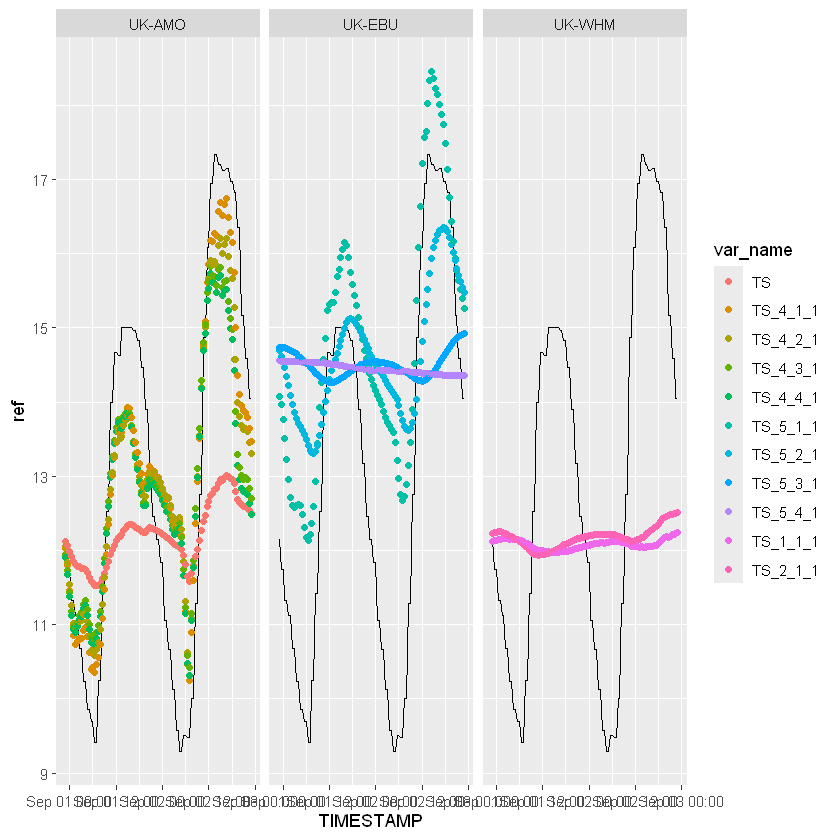

In [18]:
p <- ggplot(
  mm$dt[name_icos == "TS", ],
  aes(TIMESTAMP, value, colour = var_name)
)
p <- p + geom_line(aes(y = ref), colour = "black")
p <- p + geom_point()
p <- p + facet_wrap(~site)
print(p)

We can also plot all variable against the reference (ERA5) data to check for
anomalous deviations from the expected relationship.

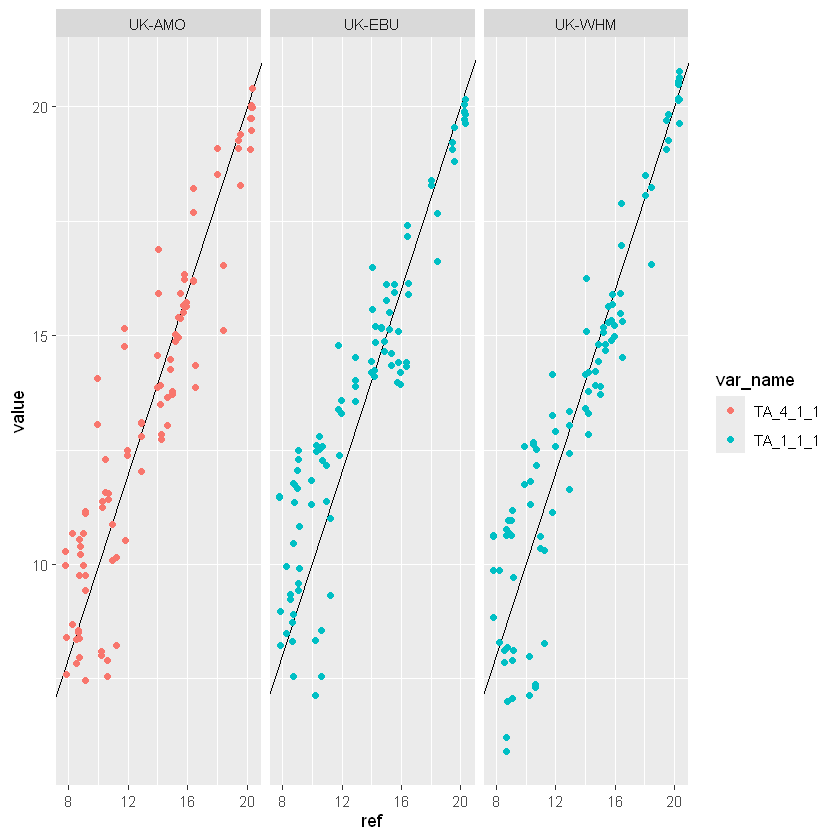

In [19]:
p <- ggplot(
  mm$dt[name_icos == "TA", ],
  aes(ref, value, colour = var_name)
)
p <- p + geom_abline()
p <- p + geom_point()
p <- p + facet_wrap(~site)
print(p)

### Using Openair Mapping Functions

This vignette illustrates the use of `openairmaps` to produce a simple 
interactive leaflet maps showing weather station sites.


## Network map

The simplest function is simply to create a network map with the `network_map` 
function shown below

In [21]:
fname_site <- here::here("inst", "extdata", "dt_site.csv")
dt_site <- data.table::fread(fname_site)
map <- network_map(dt_site)
map

Assuming "lon" and "lat" are longitude and latitude, respectively



HTML widgets cannot be represented in plain text (need html)

## Polar plot maps

We can also create interactive polar plot maps using `polar_map()`.
The function extracts the appropriate time, wind speed, and wind direction 
fields from a metamet object, and produces a leaflet-based polar map.
for a varible `var_name` chosen to be mapped.

Loading file: C:/Users/jercar/OneDrive - UKCEH/Git-Repositories/tests/metamet/inst/extdata/UK-AMO/UK-AMO_BM_dt_2026.csv



Reading data table ...



HTML widgets cannot be represented in plain text (need html)
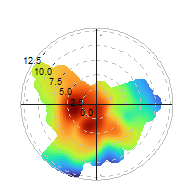

In [23]:
fname_dt <- here::here("inst", "extdata", "UK-AMO", "UK-AMO_BM_dt_2026.csv")
fname_meta <- here::here("inst", "extdata", "dt_meta.csv")
fname_site <- here::here("inst", "extdata", "dt_site.csv")
# half-hourly data
mm <- metamet(
  dt = fname_dt,
  dt_meta = fname_meta,
  dt_site = fname_site,
  site_id = "UK-AMO"
)
polar_map <- polar_map(mm, var_name = "PA_4_1_1")
polar_map